im using the breast cancer data again btw


In [2]:
%pip install optuna

  Using cached optuna-4.9.0-py3-none-any.whl.metadata (15 kB)
  Using cached alembic-1.18.5-py3-none-any.whl.metadata (7.2 kB)
  Using cached colorlog-6.12.0-py3-none-any.whl.metadata (11 kB)
  Using cached mako-1.3.12-py3-none-any.whl.metadata (2.9 kB)
Using cached optuna-4.9.0-py3-none-any.whl (425 kB)
Using cached alembic-1.18.5-py3-none-any.whl (264 kB)
   ---------------------------------------- 0.0/2.1 MB ? eta -:--:--
   ---- ----------------------------------- 0.3/2.1 MB ? eta -:--:--
   -------------- ------------------------- 0.8/2.1 MB 2.1 MB/s eta 0:00:01
   ------------------------ --------------- 1.3/2.1 MB 2.7 MB/s eta 0:00:01
   ---------------------------------- ----- 1.8/2.1 MB 2.9 MB/s eta 0:00:01
   ---------------------------------------- 2.1/2.1 MB 2.6 MB/s  0:00:00
Using cached colorlog-6.12.0-py3-none-any.whl (12 kB)
Using cached mako-1.3.12-py3-none-any.whl (78 kB)

   ----------------------------------------  0/10 [typing-extensions]
   ---- ------------------


[notice] A new release of pip is available: 26.0.1 -> 26.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import optuna
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

c:\Users\EL10_gazy\AppData\Local\Programs\Python\Python314\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Load and clean the data
Same file as Task 1, assumes data.csv is in the same folder.

In [4]:
df = pd.read_csv("data.csv")
df = df.drop(columns=[c for c in ["id", "Unnamed: 32"] if c in df.columns])

le = LabelEncoder()
df["diagnosis"] = le.fit_transform(df["diagnosis"])  # M -> 1, B -> 0

X = df.drop(columns=["diagnosis"])
y = df["diagnosis"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

## manual sweep
Before letting Optuna loose, worth seeing the shape of the curve ourselves so we know Optuna isn't doing something crazy.

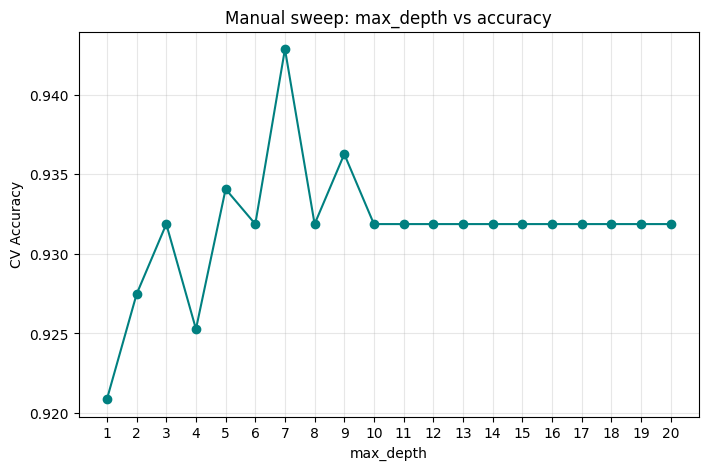

In [5]:
depths = range(1, 21)
manual_scores = []
for d in depths:
    clf = DecisionTreeClassifier(max_depth=d, random_state=42)
    score = cross_val_score(clf, X_train, y_train, cv=5, scoring="accuracy").mean()
    manual_scores.append(score)

plt.figure(figsize=(8, 5))
plt.plot(list(depths), manual_scores, marker="o", color="teal")
plt.xlabel("max_depth")
plt.ylabel("CV Accuracy")
plt.title("Manual sweep: max_depth vs accuracy")
plt.xticks(list(depths))
plt.grid(alpha=0.3)
plt.show()

## Define the Optuna objective
Optuna will search overr max_depth, we score each trial with 5-fold CV accuracy on the training set so the test set stays untouched

In [7]:
def objective(trial):
    max_depth = trial.suggest_int("max_depth", 1, 30)
    clf = DecisionTreeClassifier(max_depth=max_depth, random_state=42)
    score = cross_val_score(clf, X_train, y_train, cv=5, scoring="accuracy").mean()
    return score

## Run the study
Maximizing accuracy, 40 trials

In [8]:
optuna.logging.set_verbosity(optuna.logging.WARNING)

study = optuna.create_study(direction="maximize", study_name="decision_tree_max_depth")
study.optimize(objective, n_trials=40)

print("Best max_depth:", study.best_params["max_depth"])
print("Best CV accuracy:", study.best_value)

Best max_depth: 7
Best CV accuracy: 0.9428571428571428


## Optimization history
How the best-found accuracy evolved trial by trial.

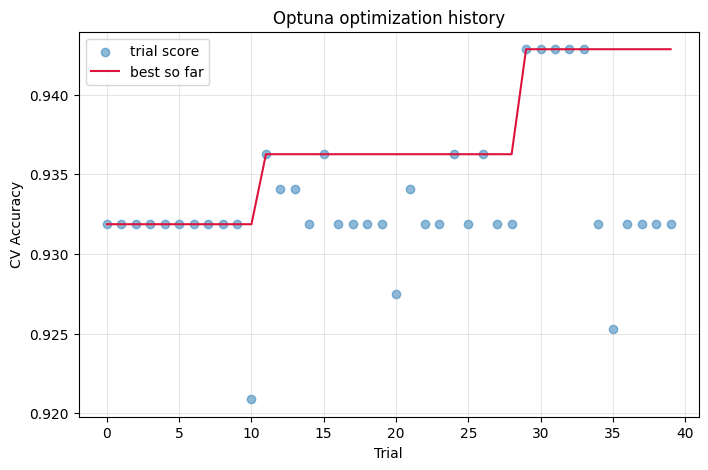

In [9]:
trial_numbers = [t.number for t in study.trials]
trial_values = [t.value for t in study.trials]
best_so_far = np.maximum.accumulate(trial_values)

plt.figure(figsize=(8, 5))
plt.scatter(trial_numbers, trial_values, alpha=0.5, label="trial score")
plt.plot(trial_numbers, best_so_far, color="crimson", label="best so far")
plt.xlabel("Trial")
plt.ylabel("CV Accuracy")
plt.title("Optuna optimization history")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

to see which depth it kept revisiting

In [10]:
trials_df = study.trials_dataframe()[["number", "value", "params_max_depth"]]
trials_df = trials_df.sort_values("value", ascending=False)
trials_df.head(10)

,number,value,params_max_depth
33,33,0.942857,7
31,31,0.942857,7
29,29,0.942857,7
30,30,0.942857,7
32,32,0.942857,7
15,15,0.936264,9
11,11,0.936264,9
24,24,0.936264,9
26,26,0.936264,9
21,21,0.934066,5


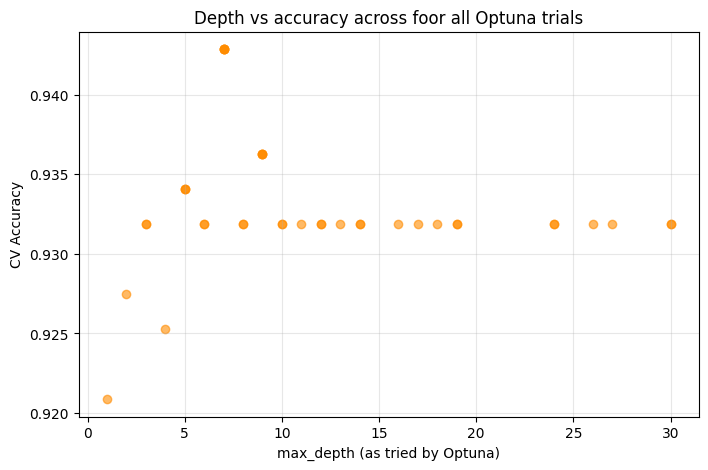

In [12]:
plt.figure(figsize=(8, 5))
plt.scatter(trials_df["params_max_depth"], trials_df["value"], color="darkorange", alpha=0.6)
plt.xlabel("max_depth (as tried by Optuna)")
plt.ylabel("CV Accuracy")
plt.title("Depth vs accuracy across foor all Optuna trials")
plt.grid(alpha=0.3)
plt.show()

## Final model with the best max_depth
Refit on the full training set and check on the untouched test set.

In [13]:
best_depth = study.best_params["max_depth"]
final_model = DecisionTreeClassifier(max_depth=best_depth, random_state=42)
final_model.fit(X_train, y_train)

test_pred = final_model.predict(X_test)
print(f"Test accuracy with max_depth={best_depth}:", accuracy_score(y_test, test_pred))

Test accuracy with max_depth=7: 0.9385964912280702
